<a href="https://colab.research.google.com/github/rahaf7777/melanoma/blob/main/melanoma.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"ra7afali","key":"c3e963cb1b2f166c2bf6ecf5b5fc36fb"}'}

In [ ]:
import os

In [ ]:
os.makedirs('/root/.config/kaggle', exist_ok=True)
os.system('cp kaggle.json /root/.config/kaggle/')
os.system('chmod 600 /root/.config/kaggle/kaggle.json')

0

In [ ]:
os.makedirs('/content/drive/MyDrive/melanoma_v2', exist_ok=True)
os.chdir('/content/drive/MyDrive/melanoma_v2')

In [ ]:
os.system('kaggle datasets download -d hasnainjaved/melanoma-skin-cancer-dataset-of-10000-images --unzip')

0

In [ ]:
import os

dataset_path = '/content/drive/MyDrive/melanoma_v2'
print("Contents of melanoma_v2:")
print(os.listdir(dataset_path))

Contents of melanoma_v2:
['melanoma-skin-cancer-dataset-of-10000-images.zip', 'melanoma_cancer_dataset', 'final_metadata.csv', 'train_split.csv', 'val_split.csv', 'test_split.csv', 'kaggle.json']


In [ ]:
inner_path = '/content/drive/MyDrive/melanoma_v2/melanoma_cancer_dataset'
print("Contents:", os.listdir(inner_path))

Contents: ['test', 'train']


In [ ]:
train_path = os.path.join(inner_path, 'train')
test_path = os.path.join(inner_path, 'test')

In [ ]:
print("\nTrain folder contents:", os.listdir(train_path))
print("Test folder contents:", os.listdir(test_path))


Train folder contents: ['benign', 'malignant']
Test folder contents: ['benign', 'malignant']


In [ ]:
train_benign = os.listdir(os.path.join(train_path, 'benign'))
train_malignant = os.listdir(os.path.join(train_path, 'malignant'))
test_benign = os.listdir(os.path.join(test_path, 'benign'))
test_malignant = os.listdir(os.path.join(test_path, 'malignant'))

In [ ]:
print("Train - benign:", len(train_benign))
print("Train - malignant:", len(train_malignant))
print("Test - benign:", len(test_benign))
print("Test - malignant:", len(test_malignant))
print("\nTotal images:", len(train_benign) + len(train_malignant) + len(test_benign) + len(test_malignant))

Train - benign: 5000
Train - malignant: 4605
Test - benign: 500
Test - malignant: 500

Total images: 10605


In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import os

In [ ]:
benign_files = os.listdir(os.path.join(train_path, 'benign'))[:3]
malignant_files = os.listdir(os.path.join(train_path, 'malignant'))[:3]

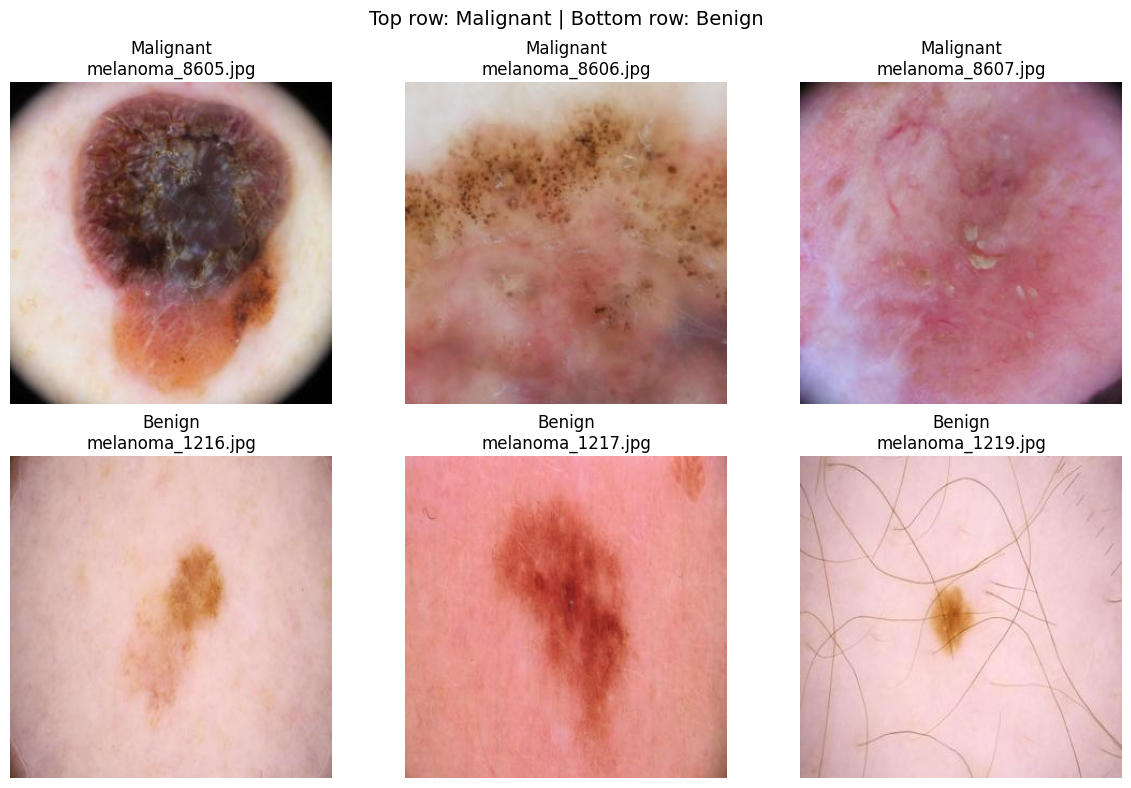

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
fig.suptitle('Top row: Malignant | Bottom row: Benign', fontsize=14)

for i, filename in enumerate(malignant_files):
    img_path = os.path.join(train_path, 'malignant', filename)
    img = Image.open(img_path)
    axes[0, i].imshow(img)
    axes[0, i].set_title(f'Malignant\n{filename}')
    axes[0, i].axis('off')

for i, filename in enumerate(benign_files):
    img_path = os.path.join(train_path, 'benign', filename)
    img = Image.open(img_path)
    axes[1, i].imshow(img)
    axes[1, i].set_title(f'Benign\n{filename}')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
sample_img = Image.open(os.path.join(train_path, 'malignant', malignant_files[0]))
print("Image size:", sample_img.size)
print("Image mode:", sample_img.mode)

Image size: (300, 300)
Image mode: RGB


In [ ]:
import pandas as pd
import os

In [ ]:
def build_dataframe(base_path, split_name):
  records = []

In [ ]:
def build_dataframe(base_path, split_name):

    records = []
    for label_name, target_value in [('benign', 0), ('malignant', 1)]:
        class_folder = os.path.join(base_path, label_name)
        filenames = os.listdir(class_folder)

        for filename in filenames:
            full_path = os.path.join(class_folder, filename)
            records.append({
                'image_path': full_path,
                'target': target_value,
                'split': split_name
            })

    return pd.DataFrame(records)

df_train = build_dataframe(train_path, 'train')
df_test = build_dataframe(test_path, 'test')

df_all = pd.concat([df_train, df_test], ignore_index=True)

print("Total images:", len(df_all))
print("\nClass distribution:")
print(df_all['target'].value_counts())
print("\nSplit distribution:")
print(df_all['split'].value_counts())
print("\nSample rows:")
print(df_all.head())

Total images: 10605

Class distribution:
target
0    5500
1    5105
Name: count, dtype: int64

Split distribution:
split
train    9605
test     1000
Name: count, dtype: int64

Sample rows:
                                          image_path  target  split
0  /content/drive/MyDrive/melanoma_v2/melanoma_ca...       0  train
1  /content/drive/MyDrive/melanoma_v2/melanoma_ca...       0  train
2  /content/drive/MyDrive/melanoma_v2/melanoma_ca...       0  train
3  /content/drive/MyDrive/melanoma_v2/melanoma_ca...       0  train
4  /content/drive/MyDrive/melanoma_v2/melanoma_ca...       0  train


In [ ]:
df_all['exists'] = df_all['image_path'].apply(os.path.exists)

print("Total images:", len(df_all))
print("Missing images:", (~df_all['exists']).sum())

Total images: 10605
Missing images: 0


In [ ]:
df_all = df_all.drop(columns=['exists'])
df_all.to_csv('/content/drive/MyDrive/melanoma_v2/final_metadata.csv', index=False)
print("Saved final_metadata.csv!")
print("Final shape:", df_all.shape)

Saved final_metadata.csv!
Final shape: (10605, 3)


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
df_trainval = df_all[df_all['split'] == 'train'].copy()
df_test_final = df_all[df_all['split'] == 'test'].copy()

df_train_final, df_val_final = train_test_split(
    df_trainval,
    test_size=0.2,
    stratify=df_trainval['target'],
    random_state=42
)

print("Train size:", len(df_train_final))
print("Validation size:", len(df_val_final))
print("Test size (untouched):", len(df_test_final))

print("\nTrain class balance:")
print(df_train_final['target'].value_counts(normalize=True))

print("\nValidation class balance:")
print(df_val_final['target'].value_counts(normalize=True))

Train size: 7684
Validation size: 1921
Test size (untouched): 1000

Train class balance:
target
0    0.520562
1    0.479438
Name: proportion, dtype: float64

Validation class balance:
target
0    0.520562
1    0.479438
Name: proportion, dtype: float64


In [ ]:
df_train_final.to_csv('/content/drive/MyDrive/melanoma_v2/train_split.csv', index=False)
df_val_final.to_csv('/content/drive/MyDrive/melanoma_v2/val_split.csv', index=False)
df_test_final.to_csv('/content/drive/MyDrive/melanoma_v2/test_split.csv', index=False)

print("All three splits saved!")

All three splits saved!


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

In [ ]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(df_train_final['target']),
    y=df_train_final['target']
)

class_weight_dict = {0: class_weights[0], 1: class_weights[1]}

print("Class weights:", class_weight_dict)

Class weights: {0: np.float64(0.9605), 1: np.float64(1.0428881650380022)}


In [ ]:
import tensorflow as tf

In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomContrast(0.2),
])

print("Augmentation pipeline created!")

Augmentation pipeline created!


In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

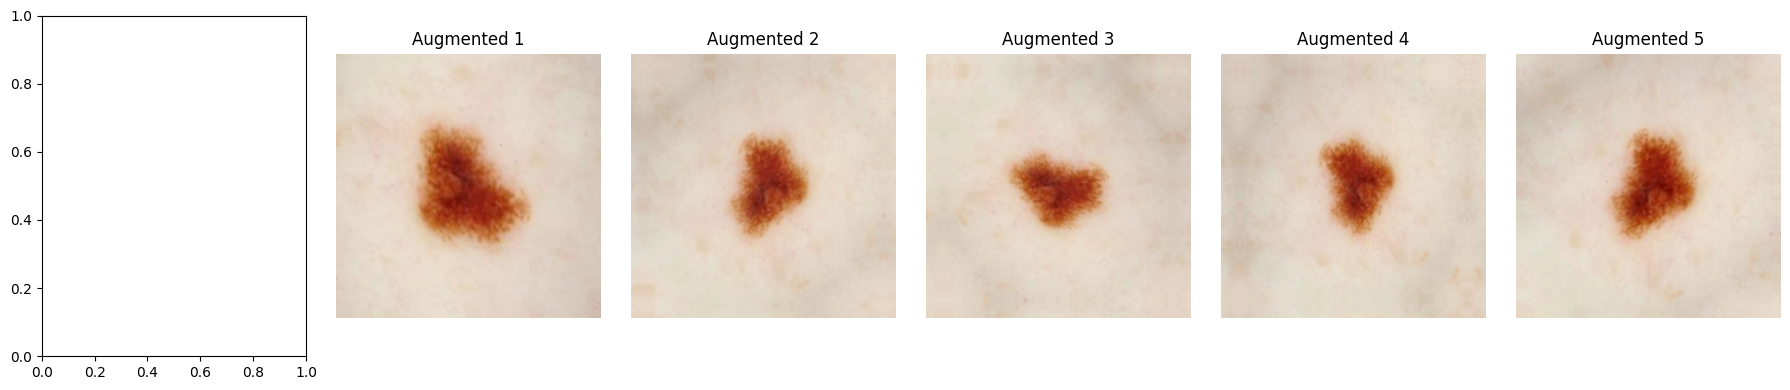

In [ ]:
sample_path = df_train_final[df_train_final['target'] == 1]['image_path'].iloc[0]
sample_img = Image.open(sample_path)
sample_array = np.array(sample_img)

sample_array = np.expand_dims(sample_array, axis=0)

fig, axes = plt.subplots(1, 6, figsize=(18, 4))

for i in range(1, 6):
    augmented = data_augmentation(sample_array, training=True)  # training=True activates the randomness
    axes[i].imshow(augmented[0].numpy().astype("uint8"))
    axes[i].set_title(f'Augmented {i}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

+ transfer learning +

In [ ]:
from google.colab import drive
import pandas as pd
import os

In [ ]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df_train = pd.read_csv('/content/drive/MyDrive/melanoma_v2/train_split.csv')
df_val = pd.read_csv('/content/drive/MyDrive/melanoma_v2/val_split.csv')
df_test = pd.read_csv('/content/drive/MyDrive/melanoma_v2/test_split.csv')

print("Train size:", len(df_train))
print("Val size:", len(df_val))
print("Test size:", len(df_test))
print("\nReady to go!")

Train size: 7684
Val size: 1921
Test size: 1000

Ready to go!


In [ ]:
import tensorflow as tf

In [ ]:
IMAGE_SIZE = (300,300)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

In [ ]:
def load_image(image_path, label):
  image = tf.io.read_file(image_path)
  image = tf.image.decode_jpeg(image, channels=3)
  image = tf.image.resize(image, IMAGE_SIZE)
  image = tf.cast(image, tf.float32) / 255.0

  return image, label

In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomContrast(0.2),
])

In [ ]:
def load_and_augment(image_path, label):
  image, label = load_image(image_path, label)
  image = tf.expand_dims(image, axis=0)
  image = data_augmentation(image, training=True)
  image = tf.squeeze(image, axis=0)

  return image, label

In [ ]:
train_dataset = tf.data.Dataset.from_tensor_slices(
    (df_train['image_path'].values, df_train['target'].values)
)
train_dataset = (train_dataset
    .map(load_and_augment, num_parallel_calls=AUTOTUNE)
    .shuffle(buffer_size=1000)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_dataset = tf.data.Dataset.from_tensor_slices(
    (df_val['image_path'].values, df_val['target'].values)
)
val_dataset = (val_dataset
    .map(load_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

print("Train batches:", len(train_dataset))
print("Val batches:", len(val_dataset))
print("\nData pipeline ready!")

Train batches: 241
Val batches: 61

Data pipeline ready!


In [ ]:
base_model = tf.keras.applications.EfficientNetB3(
    include_top=False,
    weights='imagenet',
    input_shape=(300, 300, 3)
)

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
base_model.trainable = False

In [ ]:
model = tf.keras.Sequential([
     base_model,
     tf.keras.layers.GlobalAveragePooling2D(),
     tf.keras.layers.Dropout(0.3),
     tf.keras.layers.Dense(1, activation='sigmoid')
])

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc')
    ]
)

In [ ]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb3 (Functional)     │ (None, 10, 10, 1536)   │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,537 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,785,072 (41.14 MB)

 Trainable params: 1,537 (6.00 KB)

 Non-trainable params: 10,783,535 (41.14 MB)

In [ ]:
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath='/content/drive/MyDrive/melanoma_v2/best_model.keras',
    monitor='val_auc',
    mode='max',
    save_best_only=True,
    verbose=1
)

In [ ]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_auc',
    mode='max',
    patience=5,
    verbose=1,
    restore_best_weights=True
)

In [ ]:
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_auc',
    mode='max',
    factor=0.2,
    patience=3,
    verbose=1
)

In [ ]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=20,
    class_weight={0: 0.9605, 1: 1.0428},
    callbacks=[checkpoint, early_stopping, reduce_lr]
)

print("\nTraining complete!")

Epoch 1/20
241/241 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5003 - auc: 0.5010 - loss: 0.6995
Epoch 1: val_auc improved from None to 0.69085, saving model to /content/drive/MyDrive/melanoma_v2/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/melanoma_v2/best_model.keras
241/241 ━━━━━━━━━━━━━━━━━━━━ 1384s 5s/step - accuracy: 0.5090 - auc: 0.5155 - loss: 0.6968 - val_accuracy: 0.4794 - val_auc: 0.6909 - val_loss: 0.6979 - learning_rate: 0.0010
Epoch 2/20
240/241 ━━━━━━━━━━━━━━━━━━━━ 0s 726ms/step - accuracy: 0.5145 - auc: 0.5210 - loss: 0.6957
Epoch 2: val_auc did not improve from 0.69085
241/241 ━━━━━━━━━━━━━━━━━━━━ 205s 753ms/step - accuracy: 0.5104 - auc: 0.5146 - loss: 0.6967 - val_accuracy: 0.4794 - val_auc: 0.6575 - val_loss: 0.7026 - learning_rate: 0.0010
Epoch 3/20
240/241 ━━━━━━━━━━━━━━━━━━━━ 0s 726ms/step - accuracy: 0.5007 - auc: 0.4982 - loss: 0.6991
Epoch 3: val_auc did not improve from 0.69085
241/241 ━━━━━━━━━━━━━━━━━━━━ 205s 753ms/step - acc

In [ ]:
model = tf.keras.models.load_model(
    '/content/drive/MyDrive/melanoma_v2/best_model.keras'
)

In [ ]:
base_model = model.layers[0]
base_model.trainable = True

In [ ]:
for layer in base_model.layers[:-30]:
    layer.trainable = False

In [ ]:
trainable_count = sum([1 for l in base_model.layers if l.trainable])
frozen_count = sum([1 for l in base_model.layers if not l.trainable])
print(f"Trainable layers: {trainable_count}")
print(f"Frozen layers: {frozen_count}")

Trainable layers: 30
Frozen layers: 355


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc')
    ]
)

In [ ]:
checkpoint_ft = tf.keras.callbacks.ModelCheckpoint(
    filepath='/content/drive/MyDrive/melanoma_v2/best_model_finetuned.keras',
    monitor='val_auc',
    mode='max',
    save_best_only=True,
    verbose=1
)

In [ ]:
early_stopping_ft = tf.keras.callbacks.EarlyStopping(
    monitor='val_auc',
    mode='max',
    patience=5,
    verbose=1,
    restore_best_weights=True
)

In [ ]:
reduce_lr_ft = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_auc',
    mode='max',
    factor=0.2,
    patience=3,
    verbose=1
)

In [ ]:
history_ft = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=20,
    class_weight={0: 0.9605, 1: 1.0428},
    callbacks=[checkpoint_ft, early_stopping_ft, reduce_lr_ft]
)

print("\nFine-tuning complete!")

Epoch 1/20
241/241 ━━━━━━━━━━━━━━━━━━━━ 0s 835ms/step - accuracy: 0.5117 - auc: 0.5183 - loss: 0.7088
Epoch 1: val_auc improved from None to 0.77654, saving model to /content/drive/MyDrive/melanoma_v2/best_model_finetuned.keras

Epoch 1: finished saving model to /content/drive/MyDrive/melanoma_v2/best_model_finetuned.keras
241/241 ━━━━━━━━━━━━━━━━━━━━ 307s 966ms/step - accuracy: 0.5255 - auc: 0.5340 - loss: 0.7015 - val_accuracy: 0.6897 - val_auc: 0.7765 - val_loss: 0.6852 - learning_rate: 1.0000e-04
Epoch 2/20
240/241 ━━━━━━━━━━━━━━━━━━━━ 0s 740ms/step - accuracy: 0.5296 - auc: 0.5503 - loss: 0.6949
Epoch 2: val_auc improved from 0.77654 to 0.78513, saving model to /content/drive/MyDrive/melanoma_v2/best_model_finetuned.keras

Epoch 2: finished saving model to /content/drive/MyDrive/melanoma_v2/best_model_finetuned.keras
241/241 ━━━━━━━━━━━━━━━━━━━━ 211s 775ms/step - accuracy: 0.5394 - auc: 0.5601 - loss: 0.6910 - val_accuracy: 0.5544 - val_auc: 0.7851 - val_loss: 0.6673 - learning_ra

In [ ]:
history_ft2 = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=20,
    class_weight={0: 0.9605, 1: 1.0428},
    callbacks=[checkpoint_ft, early_stopping_ft, reduce_lr_ft]
)

print("\nRound 2 training complete!")

Epoch 1/20
240/241 ━━━━━━━━━━━━━━━━━━━━ 0s 707ms/step - accuracy: 0.7449 - auc: 0.8232 - loss: 0.5155
Epoch 1: val_auc improved from 0.89233 to 0.89401, saving model to /content/drive/MyDrive/melanoma_v2/best_model_finetuned.keras

Epoch 1: finished saving model to /content/drive/MyDrive/melanoma_v2/best_model_finetuned.keras
241/241 ━━━━━━━━━━━━━━━━━━━━ 202s 740ms/step - accuracy: 0.7414 - auc: 0.8223 - loss: 0.5160 - val_accuracy: 0.8037 - val_auc: 0.8940 - val_loss: 0.4167 - learning_rate: 2.0000e-05
Epoch 2/20
240/241 ━━━━━━━━━━━━━━━━━━━━ 0s 700ms/step - accuracy: 0.7346 - auc: 0.8204 - loss: 0.5175
Epoch 2: val_auc did not improve from 0.89401
241/241 ━━━━━━━━━━━━━━━━━━━━ 199s 726ms/step - accuracy: 0.7413 - auc: 0.8219 - loss: 0.5151 - val_accuracy: 0.8069 - val_auc: 0.8939 - val_loss: 0.4155 - learning_rate: 2.0000e-05
Epoch 3/20
240/241 ━━━━━━━━━━━━━━━━━━━━ 0s 701ms/step - accuracy: 0.7398 - auc: 0.8210 - loss: 0.5126
Epoch 3: val_auc improved from 0.89401 to 0.89692, saving mo